In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from epymodelingsuite.multistrain.formatter import (
    compute_quantiles,
    add_state_abbreviations,
    compute_rate_trend_categories,
    compute_rate_trend_pmf,
    create_flusight_submission,
    RATE_TREND_CATEGORIES,
)
from epymodelingsuite.multistrain.aggregator import pull_single_strain_submission
from epymodelingsuite.schema.output import (
    get_flusight_quantiles,
    get_flusight_horizons,
    get_flusight_categorical_horizons,
)
from epymodelingsuite.utils.location import convert_location_name_format


## Configuration

Set timespan configs:

In [2]:
SUBMISSION_WEEK = "202621"
REFERENCE_DATE = "2026-05-30"
WINDOW = "202550-202620"

Choose augmentation and baseline:

In [3]:
AUGMENTED = True
BASELINE = False
BASELINE_k = 5

These configs are unlikely to need changing:

In [4]:
INCLUDE_SINGLE_STRAIN = True
DIST_FUNC = "wrmse"
STRAINS = "h1-h3-b"
TARGET = "hosp_aug" if AUGMENTED else "hosp"
TARGET_LONG = "flu_hosp_25"
SUFFIX = "_augmented" if AUGMENTED else ""
LOCAL_PARENT_DIR = "../experiments/multistrain"

Derived config values:

In [5]:
VALUE_COL = "target_total" if BASELINE else "target_sum"
MULTISTRAIN_EXPERIMENT = f"multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}"
WORKING_DIR = f"{LOCAL_PARENT_DIR}/{SUBMISSION_WEEK}-{TARGET}/{MULTISTRAIN_EXPERIMENT}"
REFERENCE_DT = pd.to_datetime(REFERENCE_DATE)
final_date = REFERENCE_DT + pd.Timedelta(weeks=4)
final_date

Timestamp('2026-06-27 00:00:00')

## Data

In [6]:
if INCLUDE_SINGLE_STRAIN:
    # Load single-strain submission file
    single_source_experiment = f"gs://gs_mobs_jessica/pipeline/flu/{SUBMISSION_WEEK}/{TARGET}_smc_{DIST_FUNC}_{WINDOW}"
    single_fname = f"output_hub_formatted.csv.gz"
    df_single = pull_single_strain_submission(source_location=single_source_experiment, fname=single_fname)
    df_single.head()

Copying gs://gs_mobs_jessica/pipeline/flu/202621/hosp_aug_smc_wrmse_202550-202620/20260527-193748-f0681c15/outputs/20260527-220224/output_hub_formatted.csv.gz to file:///tmp/tmps4dbtck1/output_hub_formatted.csv.gz
  
.


Downloaded: output_hub_formatted.csv.gz


In [7]:
# Load ground truth hospital data
fit_surv_data = pd.read_csv(f"../flu-forecast-epydemix/common-data/surveillance/{TARGET_LONG}_{SUBMISSION_WEEK}_prelim{SUFFIX}.csv")
fit_surv_data['abbreviation'] = fit_surv_data['location_iso'].apply(lambda key: key.split("-")[-1])
fit_surv_data['date'] = pd.to_datetime(fit_surv_data['target_end_date'])

# Compute quantiles
random_combined = pd.read_csv(f"{WORKING_DIR}/trajectories_aggregated.csv.gz")

traj_loc_fmt = (
    "location_name_epydemix"
    if random_combined.location.str.contains("__").any()
    else "location_name_epydemix_deprecated"
)

if BASELINE:
    baselines_avg = pd.read_csv("epymodelingsuite/data/baselines_hosp_2025.csv")
    random_combined = random_combined.merge(baselines_avg,
                                            left_on = "location",
                                            right_on=traj_loc_fmt)
    p_values = BASELINE_k / (BASELINE_k + random_combined['baseline'])
    random_combined['baseline_sample'] = np.random.negative_binomial(BASELINE_k, p_values)
    random_combined['target_total'] = random_combined['target_sum'] + random_combined['baseline_sample']
    random_combined.drop(
        columns=["location_name","location_name_epydemix","location_name_epydemix_deprecated",
                 "location_abbreviation","location_code","ISO","baseline"],
        inplace=True
    )
    random_combined.to_csv(f"{WORKING_DIR}/trajectories_aggregated.csv.gz", index=False)

random_quantiles = compute_quantiles(random_combined, value_col=VALUE_COL)

# Add abbreviations
random_quantiles = add_state_abbreviations(random_quantiles)
random_quantiles['date'] = pd.to_datetime(random_quantiles['date'])

# Get sorted list of populations (US first, then states alphabetically)
populations = sorted(random_quantiles['location'].unique())
populations = ['United_States'] + [p for p in populations if p != 'United_States']

print(f"Plotting {len(populations)} locations")

Plotting 52 locations


In [8]:
print(f"Quantiles shape: {random_quantiles.shape}")
print(f"Quantile columns: {[c for c in random_quantiles.columns if c.startswith('q')]}")
random_quantiles.head(10)

Quantiles shape: (2132, 26)
Quantile columns: ['q010', 'q025', 'q050', 'q100', 'q150', 'q200', 'q250', 'q300', 'q350', 'q400', 'q450', 'q500', 'q550', 'q600', 'q650', 'q700', 'q750', 'q800', 'q850', 'q900', 'q950', 'q975', 'q990']


,location,date,q010,q025,q050,q100,q150,q200,q250,q300,...,q650,q700,q750,q800,q850,q900,q950,q975,q990,abbreviation
0,United_States,2025-09-20,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,...,0.00,0.0,0.00,0.0,0.00,0.0,377.85,809.375,1765.43,US
1,United_States,2025-09-27,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,...,0.00,0.0,0.00,149.4,889.30,1149.5,1769.45,2256.175,2602.24,US
2,United_States,2025-10-04,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,...,0.00,174.0,751.50,1215.4,1521.75,1967.7,2480.25,2697.125,3464.67,US
3,United_States,2025-10-11,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,...,861.35,1257.6,1533.25,1920.0,2237.45,2650.0,3137.50,3557.325,4644.08,US
4,United_States,2025-10-18,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,...,1420.00,1645.3,1956.25,2191.6,2544.30,3120.3,3708.95,4300.400,4856.67,US
5,United_States,2025-10-25,0.0,0.00,0.00,0.0,0.00,0.0,0.00,313.4,...,1832.20,2087.9,2292.75,2587.0,2843.70,3398.5,4343.05,4894.400,5822.68,US
6,United_States,2025-11-01,0.0,0.00,0.00,0.0,0.00,140.0,592.25,784.4,...,2335.00,2540.9,2785.00,3105.6,3469.80,4083.4,5002.25,5753.300,6477.09,US
7,United_States,2025-11-08,0.0,0.00,0.00,0.0,447.85,800.8,994.75,1188.0,...,2923.80,3089.5,3368.25,3774.6,4260.15,4913.3,6067.70,6706.250,7708.34,US
8,United_States,2025-11-15,0.0,0.00,0.00,668.3,1101.10,1371.2,1623.75,1929.8,...,3586.80,3934.9,4225.00,4707.6,5243.90,5978.7,7223.90,8047.250,8905.18,US
9,United_States,2025-11-22,0.0,306.15,896.05,1429.8,1817.85,2196.4,2486.25,2902.7,...,4749.70,5152.5,5664.50,6068.4,6902.45,7483.1,8974.85,9868.075,10970.36,US


## Plot

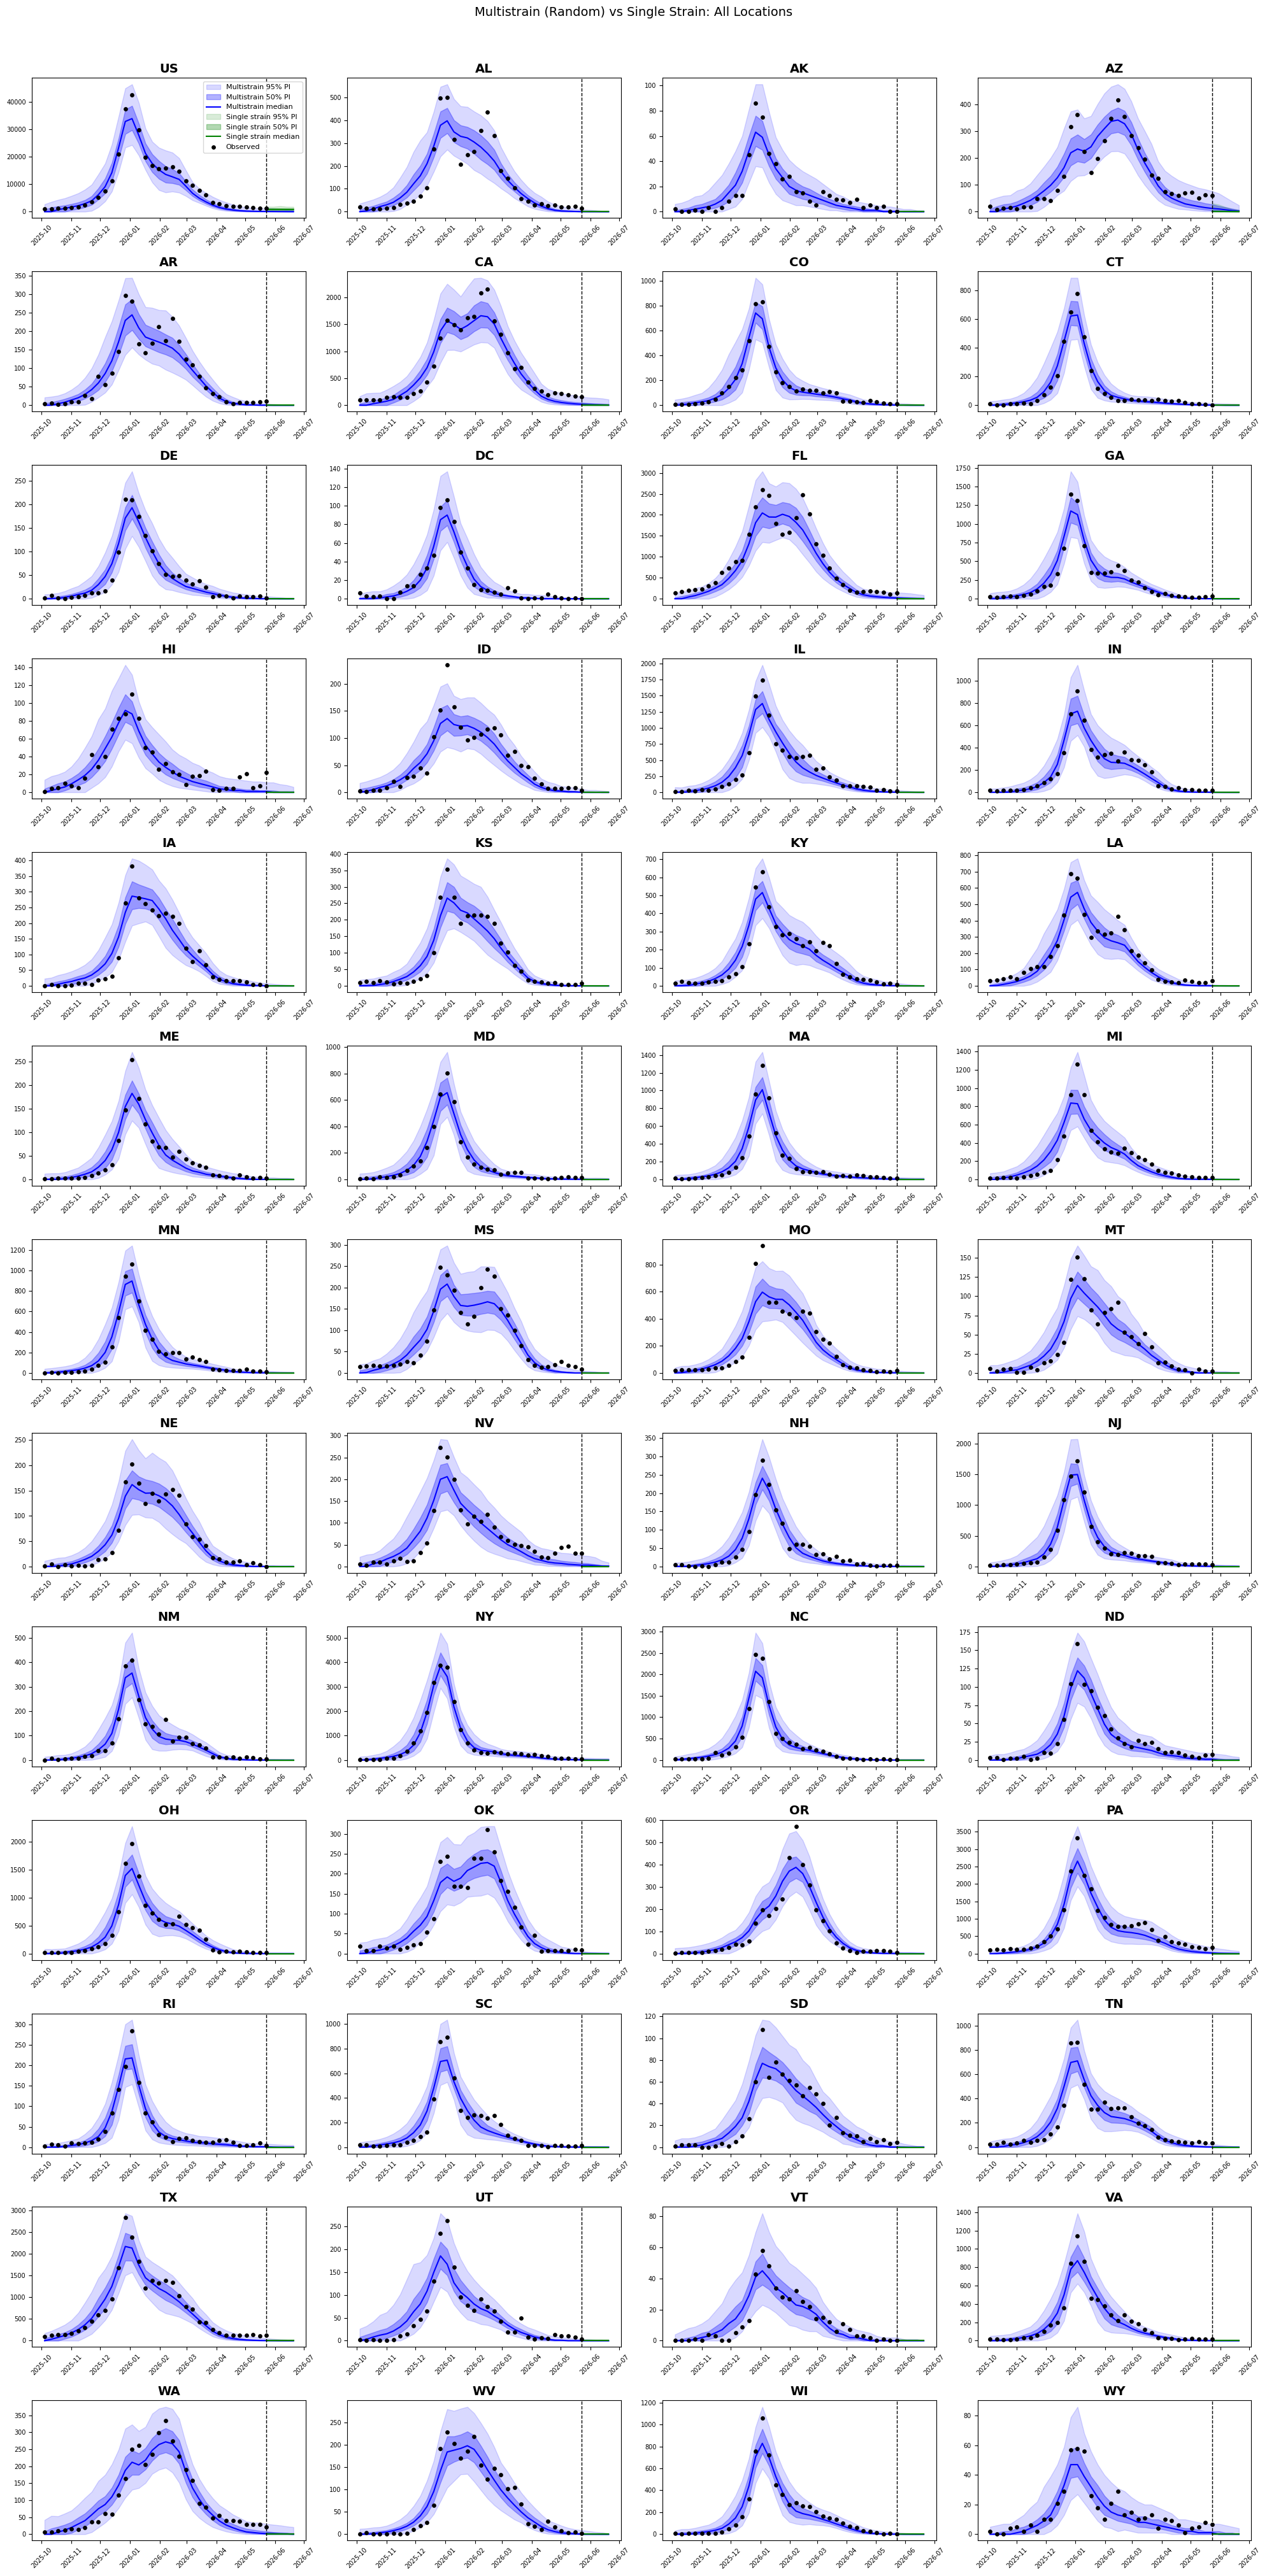

In [17]:
FILTER_PLOT = False
FILTER_PLOT_START = '2026-03-01'
LONG_PLOT_START = '2025-10-01'

if FILTER_PLOT:
    plot_start_date = pd.to_datetime(FILTER_PLOT_START)
    fname_prefix = 'filtered_'
else:
    plot_start_date = pd.to_datetime(LONG_PLOT_START)
    fname_prefix = ''

if BASELINE:
    plot_title = f'Baseline (NB k={BASELINE_k}) Multistrain (Random) vs Single Strain: All Locations'
    fname_prefix += 'baseline_'
else:
    plot_title = 'Multistrain (Random) vs Single Strain: All Locations'

plot_fname = f"{fname_prefix}{MULTISTRAIN_EXPERIMENT}_multistrain_vs_single_comparison.pdf"

# Filter data
random_quantiles_filter = random_quantiles[
    (random_quantiles['date'] >= plot_start_date) &
    (random_quantiles['date'] < final_date)
]
fit_surv_data_filter = fit_surv_data[
    (fit_surv_data['date'] >= plot_start_date) &
    (fit_surv_data['date'] < final_date)
]

if INCLUDE_SINGLE_STRAIN:
    # Convert df_single to wide format for plotting (matching random_quantiles format)
    df_single_quantiles = df_single[df_single['output_type'] == 'quantile'].copy()
    df_single_quantiles['target_end_date'] = pd.to_datetime(df_single_quantiles['target_end_date'])
    
    # Pivot to get quantile columns
    df_single_wide = df_single_quantiles.pivot_table(
        index=['location', 'target_end_date'],
        columns='output_type_id',
        values='value'
    ).reset_index()
    
    # Rename columns to match random_quantiles format
    df_single_wide.columns.name = None
    df_single_wide = df_single_wide.rename(columns={
        'target_end_date': 'date',
        '0.025': 'q025', '0.25': 'q250', '0.5': 'q500', '0.75': 'q750', '0.975': 'q975'
    })
    
    # Filter to date range
    df_single_filter = df_single_wide[
        (df_single_wide['date'] >= plot_start_date) & 
        (df_single_wide['date'] < final_date)
    ]

# Create 13x4 comparison figure: Random multistrain vs Single strain
fig, axes = plt.subplots(13, 4, figsize=(20, 40))
axes = axes.flatten()

for idx, pop in enumerate(populations):
    ax = axes[idx]
    abbrev = convert_location_name_format(
        value=pop,
        output_format="abbreviation",
        location_type="iso"
    )
    location_code = convert_location_name_format(
        value=abbrev,
        output_format="FIPS",
        input_format="abbreviation",
        location_type="iso"
    )
    
    # Get data for this population
    rand_pop = random_quantiles_filter[random_quantiles_filter['location'] == pop].sort_values('date')
    hosp_pop = fit_surv_data_filter[fit_surv_data_filter['abbreviation'] == abbrev].sort_values('date')
    if INCLUDE_SINGLE_STRAIN:
        single_pop = df_single_filter[df_single_filter['location'] == location_code].sort_values('date')
    
    # Plot random multistrain sampling (blue)
    ax.fill_between(rand_pop['date'], rand_pop['q025'], rand_pop['q975'], 
                    alpha=0.15, color='blue', label='Multistrain 95% PI')
    ax.fill_between(rand_pop['date'], rand_pop['q250'], rand_pop['q750'], 
                    alpha=0.3, color='blue', label='Multistrain 50% PI')
    ax.plot(rand_pop['date'], rand_pop['q500'], 'b-', linewidth=1.5, label='Multistrain median')
    
    # Plot single strain (green)
    if INCLUDE_SINGLE_STRAIN:
        ax.fill_between(single_pop['date'], single_pop['q025'], single_pop['q975'], 
                        alpha=0.15, color='green', label='Single strain 95% PI')
        ax.fill_between(single_pop['date'], single_pop['q250'], single_pop['q750'], 
                        alpha=0.3, color='green', label='Single strain 50% PI')
        ax.plot(single_pop['date'], single_pop['q500'], 'g-', linewidth=1.5, label='Single strain median')
    
    # Plot ground truth (black markers)
    ax.scatter(hosp_pop['date'], hosp_pop['hospitalizations'], 
               color='black', s=15, zorder=5, label='Observed')
    
    ax.set_title(abbrev, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.axvline(REFERENCE_DT - pd.Timedelta(weeks=1), color='black', linestyle='--', linewidth=1)
    
    # Only show legend for first subplot
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

# Hide any unused subplots
for idx in range(len(populations), len(axes)):
    axes[idx].set_visible(False)
    
plt.suptitle(plot_title, fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/{plot_fname}', 
            dpi=150, bbox_inches='tight')
plt.show()

## Submission File

In [10]:
# Compute rate trend categories for each trajectory
# Baseline comes from surveillance data, target from trajectories
categories_df = compute_rate_trend_categories(
    df=random_combined,
    reference_date=REFERENCE_DATE,
    surveillance_df=fit_surv_data,
    horizons=get_flusight_categorical_horizons(),
    value_col=VALUE_COL,
    surveillance_date_col='date',
    surveillance_value_col='hospitalizations',
    surveillance_location_col='abbreviation'
)

print(f"Categories computed: {len(categories_df):,} rows")
print(f"Unique populations: {categories_df['population'].nunique()}")
print(f"Horizons: {sorted(categories_df['horizon'].unique())}")
print(f"\nCategory distribution:")
print(categories_df['category'].value_counts())
print(f"\nBaseline values come from surveillance (same for all samples per location):")
categories_df.tail(10)

Categories computed: 208,000 rows
Unique populations: 52
Horizons: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Category distribution:
category
stable            185995
decrease           21902
increase             102
large_increase         1
Name: count, dtype: int64

Baseline values come from surveillance (same for all samples per location):


,reference_date,sample_id,population,abbreviation,baseline_date,horizon,target_date,baseline_value,target_value,count_change,rate_change,category
207990,2026-05-30,240,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,0.0,-6.447576,-1.097239,stable
207991,2026-05-30,221,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,0.0,-6.447576,-1.097239,stable
207992,2026-05-30,961,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,0.0,-6.447576,-1.097239,stable
207993,2026-05-30,339,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,1.0,-5.447576,-0.927061,stable
207994,2026-05-30,419,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,0.0,-6.447576,-1.097239,stable
207995,2026-05-30,847,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,0.0,-6.447576,-1.097239,stable
207996,2026-05-30,179,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,1.0,-5.447576,-0.927061,stable
207997,2026-05-30,465,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,0.0,-6.447576,-1.097239,stable
207998,2026-05-30,516,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,5.0,-1.447576,-0.246346,stable
207999,2026-05-30,529,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,0.0,-6.447576,-1.097239,stable


In [11]:
# Compute PMF from categories
pmf_df = compute_rate_trend_pmf(categories_df)

print(f"PMF shape: {pmf_df.shape}")
print(f"Columns: {pmf_df.columns.tolist()}")
print(f"\nProbabilities sum to 1: {(pmf_df[RATE_TREND_CATEGORIES].sum(axis=1).round(6) == 1).all()}")

PMF shape: (208, 9)
Columns: ['population', 'abbreviation', 'horizon', 'target_date', 'large_decrease', 'decrease', 'stable', 'increase', 'large_increase']

Probabilities sum to 1: True


In [12]:
# Format PMF for hub submission (long format)
pmf_long = pmf_df.melt(
    id_vars=['population', 'abbreviation', 'horizon', 'target_date'],
    value_vars=RATE_TREND_CATEGORIES,
    var_name='output_type_id',
    value_name='value'
)

# Add required columns for FluSight format
pmf_long['target'] = 'wk flu hosp rate change'
pmf_long['output_type'] = 'pmf'
pmf_long['location'] = pmf_long['abbreviation']

# Reorder columns
hub_pmf = pmf_long[[
    'location', 'target', 'horizon', 'target_date', 
    'output_type', 'output_type_id', 'value'
]]

print(f"Hub submission format shape: {hub_pmf.shape}")
print(f"\nSample rows:")
hub_pmf.head(15)

Hub submission format shape: (1040, 7)

Sample rows:


,location,target,horizon,target_date,output_type,output_type_id,value
0,US,wk flu hosp rate change,0,2026-05-30,pmf,large_decrease,0.0
1,US,wk flu hosp rate change,1,2026-06-06,pmf,large_decrease,0.0
2,US,wk flu hosp rate change,2,2026-06-13,pmf,large_decrease,0.0
3,US,wk flu hosp rate change,3,2026-06-20,pmf,large_decrease,0.0
4,AL,wk flu hosp rate change,0,2026-05-30,pmf,large_decrease,0.0
5,AL,wk flu hosp rate change,1,2026-06-06,pmf,large_decrease,0.0
6,AL,wk flu hosp rate change,2,2026-06-13,pmf,large_decrease,0.0
7,AL,wk flu hosp rate change,3,2026-06-20,pmf,large_decrease,0.0
8,AK,wk flu hosp rate change,0,2026-05-30,pmf,large_decrease,0.0
9,AK,wk flu hosp rate change,1,2026-06-06,pmf,large_decrease,0.0


In [13]:
# Export PMF for hub submission (uncomment to save)
# output_file = f"../data/multistrain-data/{SUBMISSION_WEEK}/rate_trend_pmf.csv"
# hub_pmf.to_csv(output_file, index=False)
# print(f"Saved PMF to: {output_file}")

# Verify probabilities sum to 1 for each location/horizon
verification = hub_pmf.groupby(['location', 'horizon'])['value'].sum()
print("All PMFs sum to 1:", (verification.round(6) == 1).all())
print(f"\nTotal PMF entries: {len(hub_pmf)}")
print(f"Locations: {hub_pmf['location'].nunique()}")
print(f"Horizons: {sorted(hub_pmf['horizon'].unique())}")
print(f"Categories per location/horizon: {len(RATE_TREND_CATEGORIES)}")

All PMFs sum to 1: True

Total PMF entries: 1040
Locations: 52
Horizons: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Categories per location/horizon: 5


In [14]:
# Create complete FluSight submission
submission = create_flusight_submission(
    trajectories_df=random_combined,
    pmf_df=pmf_df,
    reference_date=REFERENCE_DATE,
    horizons=get_flusight_horizons(),
    value_col=VALUE_COL
)

print(f"Submission shape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nTargets: {submission['target'].unique()}")
print(f"Output types: {submission['output_type'].unique()}")
print(f"Horizons: {sorted(submission['horizon'].unique())}")
print(f"Locations: {submission['location'].nunique()}")
print(f"\nRows per target:")
print(submission.groupby(['target', 'output_type']).size())

Submission shape: (7020, 8)

Columns: ['reference_date', 'horizon', 'target_end_date', 'location', 'target', 'output_type', 'output_type_id', 'value']

Targets: <StringArray>
['wk flu hosp rate change', 'wk inc flu hosp']
Length: 2, dtype: str
Output types: <StringArray>
['pmf', 'quantile']
Length: 2, dtype: str
Horizons: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Locations: 52

Rows per target:
target                   output_type
wk flu hosp rate change  pmf            1040
wk inc flu hosp          quantile       5980
dtype: int64


In [15]:
submission

,reference_date,horizon,target_end_date,location,target,output_type,output_type_id,value
0,2026-05-30,0,2026-05-30,01,wk flu hosp rate change,pmf,decrease,0.659
1,2026-05-30,0,2026-05-30,01,wk flu hosp rate change,pmf,increase,0.000
2,2026-05-30,0,2026-05-30,01,wk flu hosp rate change,pmf,large_decrease,0.000
3,2026-05-30,0,2026-05-30,01,wk flu hosp rate change,pmf,large_increase,0.000
4,2026-05-30,0,2026-05-30,01,wk flu hosp rate change,pmf,stable,0.341
...,...,...,...,...,...,...,...,...
7015,2026-05-30,3,2026-06-20,US,wk inc flu hosp,quantile,0.85,109.000
7016,2026-05-30,3,2026-06-20,US,wk inc flu hosp,quantile,0.9,198.000
7017,2026-05-30,3,2026-06-20,US,wk inc flu hosp,quantile,0.95,366.000
7018,2026-05-30,3,2026-06-20,US,wk inc flu hosp,quantile,0.975,481.000


In [16]:
sub_prefix = "baseline_" if BASELINE else ""
submission.to_csv(f"{WORKING_DIR}/{sub_prefix}{REFERENCE_DATE}-MOBS-EpyStrain_Flu.csv",
                  index=False)